# Simulador Playoffs Liga Argentina

## Preprocesamiento de datos

### En esta seccion, importamos las librerias y los datos y acomodamos caracteristicas

In [1]:
#importamos librerias
import numpy as np 
import pandas as pd 
from sklearn import svm 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV 
from sklearn.metrics import make_scorer, balanced_accuracy_score
from sklearn.pipeline import make_pipeline 
import xgboost 
from scipy import stats 
from fitter import Fitter 
import copy 
import matplotlib.pyplot as plt  
import seaborn as sns  

C:\Users\maria\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#Importamos los datos de la temporada 25/26 de la liga argentina
df = pd.read_csv("ligaArgentinaStatsCuartos.csv",sep=";")
df=df.dropna()


In [3]:
#Reconvertimos las columnas de tiros para extraer los tiros convertidos y fallados
df[["HOME_2PTM","HOME_2PTA"]]=df["HOME_2PT"].str.split("/",expand=True).astype(float)
df[["HOME_3PTM","HOME_3PTA"]]=df["HOME_3PT"].str.split("/",expand=True).astype(float)
df[["HOME_FTM","HOME_FTA"]]=df["HOME_FT"].str.split("/",expand=True).astype(float)
df[["AWAY_2PTM","AWAY_2PTA"]]=df["AWAY_2PT"].str.split("/",expand=True).astype(float)
df[["AWAY_3PTM","AWAY_3PTA"]]=df["AWAY_3PT"].str.split("/",expand=True).astype(float)
df[["AWAY_FTM","AWAY_FTA"]]=df["AWAY_FT"].str.split("/",expand=True).astype(float)

In [4]:
df

,HOME_TEAM,AWAY_TEAM,HOME_PTS,HOME_2PT,HOME_2PT_PCT,HOME_3PT,HOME_3PT_PCT,HOME_FT,HOME_FT_PCT,HOME_DEF_REB,...,HOME_3PTM,HOME_3PTA,HOME_FTM,HOME_FTA,AWAY_2PTM,AWAY_2PTA,AWAY_3PTM,AWAY_3PTA,AWAY_FTM,AWAY_FTA
0,El Talar,Quilmes,82,24/39,61,7/18,38,13/14,92,30,...,7.0,18.0,13.0,14.0,14.0,30.0,9.0,27.0,15.0,18.0
1,Central Entrerriano,Ciclista,95,24/38,63,12/31,38,11/15,73,28,...,12.0,31.0,11.0,15.0,17.0,38.0,10.0,24.0,15.0,22.0
2,Racing Avellaneda,Provincial,63,13/32,40,8/29,27,13/23,56,21,...,8.0,29.0,13.0,23.0,23.0,34.0,4.0,20.0,19.0,26.0
3,Centenario,La Union Colon,76,14/31,45,13/31,41,9/11,81,22,...,13.0,31.0,9.0,11.0,24.0,43.0,5.0,24.0,15.0,18.0
4,Comunicaciones,Jujuy,84,21/32,65,8/23,34,18/28,64,36,...,8.0,23.0,18.0,28.0,14.0,32.0,8.0,33.0,16.0,27.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,Central Entrerriano,Gimnasia La Plata,90,22/36,61,9/27,33,19/31,61,34,...,9.0,27.0,19.0,31.0,18.0,37.0,11.0,33.0,15.0,18.0
607,Barrio Parque,Comunicaciones,76,16/35,45,13/34,38,5/10,50,30,...,13.0,34.0,5.0,10.0,17.0,38.0,6.0,22.0,9.0,16.0
608,Lanus,Quilmes,86,21/32,65,11/29,37,11/19,57,29,...,11.0,29.0,11.0,19.0,19.0,40.0,5.0,23.0,19.0,31.0
609,Amancay,Villa San Martin,68,22/48,45,5/20,25,9/14,64,23,...,5.0,20.0,9.0,14.0,19.0,34.0,5.0,18.0,10.0,19.0


In [5]:
#convertimos los porcentajes a por 100
df["HOME_2PT_PCT"]=(df["HOME_2PTM"]/df["HOME_2PTA"])*100
df["HOME_3PT_PCT"]=(df["HOME_3PTM"]/df["HOME_3PTA"])*100
df["HOME_FT_PCT"]=(df["HOME_FTM"]/df["HOME_FTA"])*100
df["AWAY_2PT_PCT"]=(df["AWAY_2PTM"]/df["AWAY_2PTA"])*100
df["AWAY_3PT_PCT"]=(df["AWAY_3PTM"]/df["AWAY_3PTA"])*100
df["AWAY_FT_PCT"]=(df["AWAY_FTM"]/df["AWAY_FTA"])*100

In [6]:
#creamos una variable categorica para ver si gano de local el partido
df["HOME_WINS"]=(df["HOME_PTS"]>df["AWAY_PTS"]).astype(int)

In [7]:
#convertimos el dataset en numerico para que funcione nuestro modelo
dfNumerical=df[['HOME_TEAM',
 'AWAY_TEAM',
 'HOME_PTS',
 'HOME_2PTM',
 'HOME_2PTA',
 'HOME_2PT_PCT',
 'HOME_3PTM',
 'HOME_3PTA',                 
 'HOME_3PT_PCT',
 'HOME_FTM',
 'HOME_FTA',                  
 'HOME_FT_PCT',
 'HOME_DEF_REB',
 'HOME_OFF_REB',
 'HOME_TOT_REB',
 'HOME_AST',
 'HOME_STL',
 'HOME_TOV',
 'HOME_COM_BLK',
 'HOME_REC_BLK',
 'HOME_COM_PF',
 'HOME_REC_PF',
 'HOME_RNK',
 'AWAY_PTS',
 'AWAY_2PTM',
 'AWAY_2PTA',
 'AWAY_2PT_PCT',
 'AWAY_3PTM',
 'AWAY_3PTA',
 'AWAY_3PT_PCT',
 'AWAY_FTM',
 'AWAY_FTA',
 'AWAY_FT_PCT',
 'AWAY_DEF_REB',
 'AWAY_OFF_REB',
 'AWAY_TOT_REB',
 'AWAY_AST',
 'AWAY_STL',
 'AWAY_TOV',
 'AWAY_COM_BLK',
 'AWAY_REC_BLK',
 'AWAY_COM_PF',
 'AWAY_REC_PF',
 'AWAY_RNK',
 'HOME_WINS']]

## Modelo y entrenamiento

### En esta seccion, haremos el modelado de simulacion y entrenamiento de datos definitivo. Usaremos XGBoost, que se caracteriza por su eficiencia y escalabilidad en grandes datos, ademas de usar arboles de decisiones (que son muy buenos para problemas de clasificacion como en este caso que queremos ver si gana de local o no el partido), combinandolos con una tecnica llamada boosting, que justamente fortalece las estimaciones en modelos con alta tendencia a valores totalmente aleatorios (como en este caso de prediccion deportiva), minimizando el error de prediccion

In [8]:
#Creamos la X, que son las variables independientes
X=dfNumerical[[
 'HOME_PTS',
 'HOME_2PTM',
 'HOME_2PTA',
 'HOME_2PT_PCT',
 'HOME_3PTM',
 'HOME_3PTA',                 
 'HOME_3PT_PCT',
 'HOME_FTM',
 'HOME_FTA',                  
 'HOME_FT_PCT',
 'HOME_DEF_REB',
 'HOME_OFF_REB',
 'HOME_TOT_REB',
 'HOME_AST',
 'HOME_STL',
 'HOME_TOV',
 'HOME_COM_BLK',
 'HOME_REC_BLK',
 'HOME_COM_PF',
 'HOME_REC_PF',
 'HOME_RNK',
 'AWAY_PTS',
 'AWAY_2PTM',
 'AWAY_2PTA',
 'AWAY_2PT_PCT',
 'AWAY_3PTM',
 'AWAY_3PTA',
 'AWAY_3PT_PCT',
 'AWAY_FTM',
 'AWAY_FTA',
 'AWAY_FT_PCT',
 'AWAY_DEF_REB',
 'AWAY_OFF_REB',
 'AWAY_TOT_REB',
 'AWAY_AST',
 'AWAY_STL',
 'AWAY_TOV',
 'AWAY_COM_BLK',
 'AWAY_REC_BLK',
 'AWAY_COM_PF',
 'AWAY_REC_PF',
 'AWAY_RNK']]

In [9]:
#Creamos y que es la variable objetivo
y=dfNumerical['HOME_WINS']

In [10]:
#convertimos a numpy
X=X.to_numpy()
y=y.to_numpy()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, random_state=42) #Separamos los datos en datos de entrenamiento y de test

print("X shape", X_train.shape, "y shape", y_train.shape)
scaler = StandardScaler() # estandarizamos los datos 
X_train = scaler.fit_transform(X_train) #entrenamos los datos


X shape (488, 42) y shape (488,)


In [12]:
clf = xgboost.XGBClassifier(    
) # inicializamos el algoritmo de XGBoost
clf.fit(X_train, y_train) # entrenamos
y_pred = clf.predict(X_test) #predecimos 
print('balanced accuracy score:', balanced_accuracy_score(y_test, y_pred)) 

balanced accuracy score: 0.5


In [13]:
scoring = make_scorer(balanced_accuracy_score)
param_dist = {
    'n_estimators': np.arange(100, 401, 50),        
    'max_depth': np.arange(3, 9),                   
    'learning_rate': np.linspace(0.01, 0.2, 10),    
    'subsample': np.linspace(0.6, 1.0, 5),
    'colsample_bytree': np.linspace(0.6, 1.0, 5),
    'gamma': np.linspace(0, 0.3, 6)
} #Decretamos los hiperparametros principales

random_search = RandomizedSearchCV(
    clf,
    param_distributions=param_dist,
    n_iter=30,              
    scoring=scoring,
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
) #hacemos busqueda de los mejores hiperparametros para nuestro modelo

random_search.fit(X_train, y_train) #entrenamos

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                        'gamma': array([0.  , 0.06, 0.12, 0.18, 0.24, 0.3 ]),
                                        'learning_rate': array([0.01      , 0.03111111, 0.05222222, 0.07333333, 0.09444444,
       0.11555556, 0.13666667, 0.15777778, 0.17888889, 0.2       ]),
                                        'max_depth': array([3, 4, 5, 6, 7, 8]),
                                        'n_estimators': array([100, 150, 200, 250, 300, 350, 400]),
                                        'subsample': array([0.6, 0.7, 0.8, 0.9, 1. ])},
                   random_state=42,
                   scoring=make_scorer(balanced_accuracy_score, response_method='predict'),
                   verbose=2)

In [14]:
Dis = random_search.best_estimator_
print(Dis) #imprimos el mejor estimador

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.9), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(0.18), grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.07333333333333333), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(3), max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(100), n_jobs=None,
              num_parallel_tree=None, ...)


In [15]:
selected_distributions = [
    'norm','t', 'f', 'chi', 'cosine', 'alpha', 
    'beta', 'gamma', 'dgamma', 'dweibull',
    'maxwell', 'pareto', 'fisk']
#distribuciones para simular

In [16]:
#creamos el dataframe definitivo
dfTotal=df[['HOME_TEAM',
 'AWAY_TEAM',
 'HOME_PTS',
 'HOME_2PTM',
 'HOME_2PTA',
 'HOME_2PT_PCT',
 'HOME_3PTM',
 'HOME_3PTA',                 
 'HOME_3PT_PCT',
 'HOME_FTM',
 'HOME_FTA',                  
 'HOME_FT_PCT',
 'HOME_DEF_REB',
 'HOME_OFF_REB',
 'HOME_TOT_REB',
 'HOME_AST',
 'HOME_STL',
 'HOME_TOV',
 'HOME_COM_BLK',
 'HOME_REC_BLK',
 'HOME_COM_PF',
 'HOME_REC_PF',
 'HOME_RNK',
 'AWAY_PTS',
 'AWAY_2PTM',
 'AWAY_2PTA',
 'AWAY_2PT_PCT',
 'AWAY_3PTM',
 'AWAY_3PTA',
 'AWAY_3PT_PCT',
 'AWAY_FTM',
 'AWAY_FTA',
 'AWAY_FT_PCT',
 'AWAY_DEF_REB',
 'AWAY_OFF_REB',
 'AWAY_TOT_REB',
 'AWAY_AST',
 'AWAY_STL',
 'AWAY_TOV',
 'AWAY_COM_BLK',
 'AWAY_REC_BLK',
 'AWAY_COM_PF',
 'AWAY_REC_PF',
 'AWAY_RNK',
 'HOME_WINS']]
dfTotal=dfTotal.dropna()

In [17]:
#variables independiente
selected_features=[
 'HOME_PTS',
 'HOME_2PTM',
 'HOME_2PTA',
 'HOME_2PT_PCT',
 'HOME_3PTM',
 'HOME_3PTA',                 
 'HOME_3PT_PCT',
 'HOME_FTM',
 'HOME_FTA',                  
 'HOME_FT_PCT',
 'HOME_DEF_REB',
 'HOME_OFF_REB',
 'HOME_TOT_REB',
 'HOME_AST',
 'HOME_STL',
 'HOME_TOV',
 'HOME_COM_BLK',
 'HOME_REC_BLK',
 'HOME_COM_PF',
 'HOME_REC_PF',
 'HOME_RNK',
 'AWAY_PTS',
 'AWAY_2PTM',
 'AWAY_2PTA',
 'AWAY_2PT_PCT',
 'AWAY_3PTM',
 'AWAY_3PTA',
 'AWAY_3PT_PCT',
 'AWAY_FTM',
 'AWAY_FTA',
 'AWAY_FT_PCT',
 'AWAY_DEF_REB',
 'AWAY_OFF_REB',
 'AWAY_TOT_REB',
 'AWAY_AST',
 'AWAY_STL',
 'AWAY_TOV',
 'AWAY_COM_BLK',
 'AWAY_REC_BLK',
 'AWAY_COM_PF',
 'AWAY_REC_PF',
 'AWAY_RNK',
 ]

In [18]:
unique_teams = dfTotal['HOME_TEAM'].unique() # extramos los equipos participantes (solo por control)

#obtenemos los datos de local y visitante de cada equipo
all_team_sim_data = {}

for team_name in unique_teams:
    
    # encontramos juegos donde el equipo es visitante o local
    df_team = dfTotal.loc[(dfTotal['HOME_TEAM'] == team_name) | (dfTotal['AWAY_TEAM'] == team_name)]
    # si es local tomamos las primeras 21 features, sino las ultimas 21
    df_1 = df_team.loc[df_team['HOME_TEAM'] == team_name][selected_features[:21]]
    df_0 = df_team.loc[df_team['AWAY_TEAM'] == team_name][selected_features[21:]]
    # unificamos las columnas
    df_0.columns = df_1.columns 
    
    # terminamos de formar los daots
    all_team_sim_data[team_name] = {"home":df_1.to_numpy(),"away":df_0.to_numpy()}
   

In [19]:
unique_teams = dfTotal['AWAY_TEAM'].unique()
unique_teams

<ArrowStringArray>
[            'Quilmes',            'Ciclista',          'Provincial',
      'La Union Colon',               'Jujuy', 'Estudiantes Tucuman',
               'Colon',       'Hindu Cordoba',           'Pergamino',
          'Centenario', 'Central Entrerriano',   'Huracan Las Heras',
       'Barrio Parque',            'Rocamora',      'Comunicaciones',
      'Fusion Riojana',   'Independiente Sde',           'Union Mdp',
               'Salta',       'Pico Football',   'Racing Avellaneda',
             'Amancay',              'Suardi',   'Gimnasia La Plata',
     'Deportivo Norte',               'Lanus',              'Viedma',
    'Villa San Martin',          'San Isidro',            'El Talar',
           'Rivadavia',         'Villa Mitre',              'Bochas',
         'Santa Paula']
Length: 34, dtype: str

In [20]:
megadata = {} # almacenamos los datos en un generados
for team_name in unique_teams:
    team_info={}
    for loc in ["home","away"]:
        feature_dis_paras = []
        data = all_team_sim_data[team_name][loc].astype(float)
        # 21 features por cada equipo
        for i in range(21): 
            f = Fitter(data[:, i]) # inicializamos el Fitter
            f.distributions = selected_distributions # usamos las distribuciones
            f.fit() # entrenamos
            best_paras = f.get_best(method='sumsquare_error') # get the best fitted paras
            feature_dis_paras.append(best_paras)
        team_info[loc]=feature_dis_paras
        
    megadata[team_name] = team_info
    
print('Features for all teams have been fitted!')

Features for all teams have been fitted!


In [21]:

DATA = megadata.copy() # data that Generator must rely on

GEN = {
 'alpha': stats.alpha.rvs,
 'beta': stats.beta.rvs,
 'chi': stats.chi.rvs,
 'cosine': stats.cosine.rvs,
 'dgamma': stats.dgamma.rvs,
 'dweibull':stats.dweibull.rvs,
 'f':stats.f.rvs,
 'fisk':stats.fisk.rvs,
 'gamma': stats.gamma.rvs,
 'maxwell':stats.maxwell.rvs,
 'norm':stats.norm.rvs,
 'pareto':stats.pareto.rvs,
 't':stats.t.rvs,
}

In [22]:
# feature scaler + fine-turned SVM 
DIS = make_pipeline(scaler, Dis)

## Prediccion

### En esta seccion haremos finalmente el modelo de prediccion, con la clase Game (que simboliza a los partidos), y la clase Tournament (que simboliza los torneos). Lo que calcularemos es la probabilidad de ascenso y de ganar una serie para todos los equipos 

In [23]:
#Partidos
class Game:
    
    def __init__ (self, random_state = None):
        
        self.random_state = random_state 
    #predecimos partidos
    def predict(self, team1, team2, num_games = 1):
        
        assert num_games >= 1, "al menos un juego debe jugarse"
        team_1_feature_data = DATA[team1]["home"]
        team_2_feature_data = DATA[team2]["away"]
        features = []
        for feature_paras_1 in team_1_feature_data:
            sample_1 = self.sampling(feature_paras_1, size = num_games) 
            features.append(sample_1) 
            
        for feature_paras_2 in team_2_feature_data:
            sample_2 = self.sampling(feature_paras_2, size = num_games) 
            features.append(sample_2)   
        features = np.array(features).T
        win_loss = DIS.predict(features)
        
        return list(win_loss) # lista de perdidos/ganados
    
    
    def sampling(self, dic, size = 1, random_state = None):
        
                        
        dis_name = list(dic.keys())[0] # get the type
        paras = list(dic.values())[0] # get the paras
        paras_values = list(paras.values())
    
        sample = GEN[dis_name](*paras_values, size = size,  random_state =  random_state)
            
        return sample 

In [24]:
#Torneo
class FinalTournament(Game):
    
    
    def __init__(self, n_games_per_group = 5, winning_threshold = 3, random_state = None):

        self.n_games_per_group  = n_games_per_group #cantidad de juegos de playoff
        self.winning_threshold = winning_threshold #cantidad de juegos a ganar como minimo para ganar la serie
        self.team_list = None
        self.team_rankings=[]
        self.rounds = {} # numero de rondas
        super().__init__(random_state)
        
  #Simulamos el torneo  
    def simulate(self, group_list, n_simulation = 1, probs = True):
        
        self.rounds = {}
        self.team_list = [i[0] for i in group_list] + [i[1] for i in group_list]
        
        for i in range(n_simulation):
            #ranking general de la liga
            self.team_rankings=['San Isidro', 'Lanus','Barrio Parque','La Union Colon','Santa Paula','Gimnasia La Plata','Viedma','Villa San Martin'] 
            cham = self.one_time_simu(group_list)
        if probs:
            self.rounds_probs =  self._compute_probs()
            
    
    def one_time_simu(self, group_list, verbose = False, probs = False):
        
       
        if self.team_list == None: 
            self.team_list = [i[0] for i in group_list] + [i[1] for i in group_list]
        round_number, done = 0, 0
        while not done: 
            all_group_winners, group_list = self.play_round(group_list)
            
            try:
                updated_round_stats = self.rounds[round_number]
            except KeyError:
                updated_round_stats = {}
                for team in self.team_list:
                    updated_round_stats[team] = 0
          
            for winner in all_group_winners:
                try: 
                    updated_round_stats[winner] += 1
                except KeyError:
                    pass     
            self.rounds[round_number] = updated_round_stats
        
            if verbose:
                print('{} round played'.format(round_number))
            if probs:
                self.rounds_probs = self._compute_probs()
            if type(group_list) != list:
                done = 1
            round_number += 1
            
        return group_list

    #jugamos cada ronda    
    def play_round(self, group_list):
        
        all_group_winners = [] 
        for group in group_list:
            winner = self.play_n_games(group[0], group[1])
            all_group_winners.append(winner)
        
        if len(all_group_winners) > 1:
            new_group_list = []    
            #Siempre se juega en la cancha del mejor ubicado
            for index in range(0, len(all_group_winners), 2):
                
                team1=all_group_winners[index]
                team2=all_group_winners[index + 1]
                if self.team_rankings.index(team1)<self.team_rankings.index(team2):
                    new_group = [team1,team2]
                else:
                    new_group = [team2,team1]
                new_group_list.append(new_group)
                
            return all_group_winners, new_group_list
        else:  
            return all_group_winners, winner
        
    #jugamos n juegos    
    def play_n_games(self, team1, team2):
        
        #Victorias de equipo con ventaja de localia
        wins_team1=0
        #Victorias de equipo sin ventaja de localia
        wins_team2=0
        game=0
        #Las series son 2-2-1, es decir primero juega 2 veces un equipo de local, luego otro y asi sucesivamente, siempre el mejor juega primero
        series=[(team1,team2,2,True),(team2,team1,2,False),(team1,team2,1,True)]
        #A partir de aqui, se toma como 1 las victorias de local de cada partido,
        for home,away,games_played,team1_is_home in series:
            result = Game().predict(home,away,games_played)
            for r in result:
                if r==1:
                    if team1_is_home:
                        wins_team1+=1
                    else:
                        wins_team2+=1
                else:
                    if team1_is_home:
                        wins_team2+=1
                    else:
                        wins_team1+=1
            #Playoff termina tras 3 partidos ganados por parte de un equipo            
            if wins_team1==self.winning_threshold or wins_team2==self.winning_threshold:
                break
        if wins_team1==self.winning_threshold:
            winner=team1
        else:
            winner=team2
        return winner  
    #sacamos probabilidades    
    def _compute_probs(self):
        
        
        rounds_probs = copy.deepcopy(self.rounds)
        for round_number, round_stats in rounds_probs.items():
            m = np.sum(list(round_stats.values()))
            for k, v in rounds_probs[round_number].items():
                rounds_probs[round_number][k] = v / 5000
                
        return rounds_probs

In [26]:

group_list = [
     ('Lanus', 'Villa San Martin'),  # group A 
     ('Barrio Parque', 'Gimnasia La Plata'), # group B
    
     ('San Isidro', 'Viedma'), # group C
     ('La Union Colon', 'Santa Paula'), # group D
]

In [27]:
%%time

# iniciamos el playoff
playoff = FinalTournament()
# simulamos playoff
playoff.simulate(group_list, n_simulation = 5000)

CPU times: total: 1h 31min 23s
Wall time: 8min 41s


## Probabilidades finales

### Aqui veremos las probabilidades de ascender y/o ganar la serie de cada equipo. La serie 2 simboliza final por el ascenso (y chances de ascender), la 0 simboliza los cuartos de final nacionales, y la 1 simboliza los simboliza las semifinales nacionales. Es decir en la parte 0, decimos "la probabilidad de un equipo de llegar a las semifinales" y asi sucesivamente

In [28]:
#Vemos las probabilidades
playoff.rounds_probs

{0: {'Lanus': 0.6028,
  'Barrio Parque': 0.634,
  'San Isidro': 0.8548,
  'La Union Colon': 0.6898,
  'Villa San Martin': 0.3972,
  'Gimnasia La Plata': 0.366,
  'Viedma': 0.1452,
  'Santa Paula': 0.3102},
 1: {'Lanus': 0.3942,
  'Barrio Parque': 0.3096,
  'San Isidro': 0.7204,
  'La Union Colon': 0.1596,
  'Villa San Martin': 0.1396,
  'Gimnasia La Plata': 0.1566,
  'Viedma': 0.0332,
  'Santa Paula': 0.0868},
 2: {'Lanus': 0.2634,
  'Barrio Parque': 0.1216,
  'San Isidro': 0.435,
  'La Union Colon': 0.0658,
  'Villa San Martin': 0.0292,
  'Gimnasia La Plata': 0.0328,
  'Viedma': 0.013,
  'Santa Paula': 0.0392}}

### Con 43.50% de chances de ascender, el candidato a ascender a la proxima Liga Nacional es el club San Isidro de San Francisco

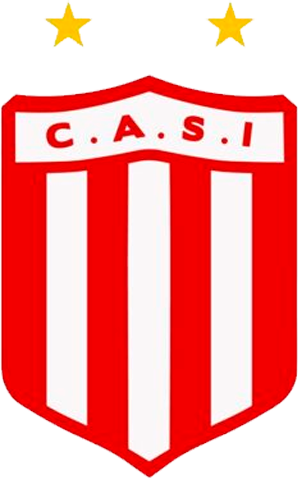

In [30]:
from IPython.display import Image
Image("san-isidro.jpg")